<a href="https://colab.research.google.com/github/frederickbernard229-code/cambridge-pace/blob/main/course_1_statistics/CAM_DS_C101_Activity_2_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**First things first** - please go to 'File' and select 'Save a copy in Drive' so that you have your own version of this activity set up and ready to use.
Remember to update your Course 1 notebook with links to your own work once completed!

# Activity 2.2.3 Interpreting correlation

## Scenario
You are a data analyst working for a large investment firm in London. The organisation is considering offering medical insurance as an employment benefit, but the management team needs to consider the potential cost of claims before they make any decisions. The team has received quotes from five medical insurers, and the cost of the insurance varies widely.

One insurer has delivered a very competitive quote, but the downside is that the cost per person would vary depending on certain criteria set by the insurance company. These criteria include body mass index (BMI). The insurance would be affordable for all those with a BMI in the range of 18–24, but any employee outside of these categories would have to pay an additional monthly contribution. This may lead to the management team being accused of bias against these employees, as some employees would receive free insurance while others would have to pay.

Your company is considering developing more targeted insurance plans and policies based on individual lifestyles. This would involve offering incentives for healthier living or adjusting premiums based on certain lifestyle choices. However, before implementing these changes, the company wants to gather evidence of any correlations between lifestyle choices and insurance costs.

Your organisation would like to be able to evidence the impact of lifestyle choices on the medical insurance costs so that it can explain why some employees would have to pay extra to be in the scheme. To gather this evidence, it would like to explore the correlations between lifestyle choices and potential insurance costs.

Your goal is to identify correlations in an anonymised data set that contains information about individuals and their medical insurance costs. The data set includes demographic data (age) and health and lifestyle data (BMI, and number of children). The management team would like you to explore which of these factors would have a significant effect on insurance costs.


## Objective
Your goal is to identify correlations in an anonymised data set that contains information about individuals and their medical insurance costs.


## Assessment criteria
By completing this activity, you will be able to provide evidence that you can:
*   Investigate data systematically to identify links and account for biases.
*   Interpret statistical test results rigorously, identifying and addressing assumptions and limitations


## Activity guide
1. **Libraries and data:**
Import the necessary Python libraries and run the cell to load the data set.
2. **Data exploration:**
Explore the data set.
Calculate descriptive statistics and create visualisations (scatter plots, histograms, etc.).
Gain a general understanding of the data.
3. **Statistical testing:**
Conduct a correlation analysis on the specified variables using Python libraries such as Pandas and NumPy.
Calculate correlation coefficients (e.g. Pearson or Spearman) and p-values.
4. **Interpretation:**
Interpret the correlation coefficients and p-values.
5. **State limitations:**
Describe the limitations of correlation analysis.
Consider potential biases affecting interpretation.
6. **Reflecting and documenting:**
Reflect on findings.
Describe the entire analysis process, including exploration, statistical testing, and interpretation.
Mention any assumptions and limitations in the analysis.

> Start your activity here. Select the pen from the toolbar to add your entry.

In [1]:
# Import libraries
import pandas  as pd #Data manipulation
import numpy as np #Data manipulation
import matplotlib.pyplot as plt #Visualisation
import seaborn as sns #Visualisation

data = pd.read_csv("https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/insurance_updated.csv")

In [2]:
data.head()

,age,bmi,number_of_children,charges
0,47,29.45,1,25000
1,34,32.14,0,24666
2,39,21.62,1,18301
3,52,25.84,1,19252
4,48,26.82,1,24014


--- Summary Statistics ---
               age         bmi  number_of_children       charges
count  1000.000000  1000.00000         1000.000000   1000.000000
mean     29.674000    25.35935            0.966000  24634.033000
std       8.800749     6.96078            0.932584   7766.545578
min      18.000000    15.00000            0.000000  10858.000000
25%      22.750000    19.76750            0.000000  18758.000000
50%      29.000000    25.20500            1.000000  23970.000000
75%      36.000000    30.00250            2.000000  29200.750000
max      57.000000    40.00000            4.000000  50597.000000


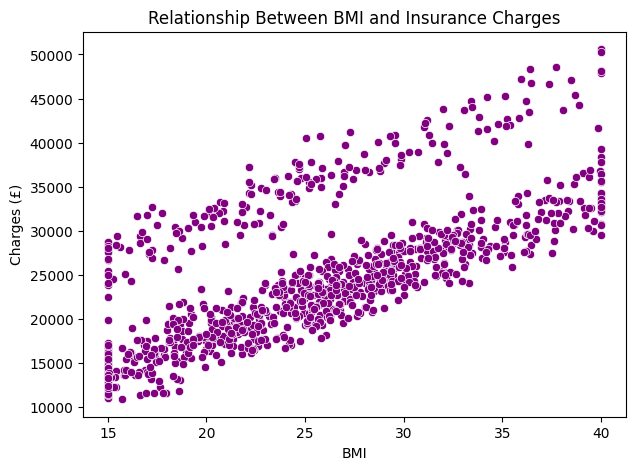

In [4]:
# 1. Get descriptive statistics for all columns
print("--- Summary Statistics ---")
print(data.describe())

# 2. Create a scatter plot to see how BMI relates to insurance Charges
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.scatterplot(data=data, x='bmi', y='charges', color='purple')
plt.title('Relationship Between BMI and Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (£)')
plt.show()

# Data Exploration:

**The Mean, Median, and Mode**
The data in the table labelled --- Summary Statistics --- shows:

**Count:** You have exactly **1000** rows of data.
**Mean (Average):** The mean BMI is **25.36.**

		○ The mean insurance charge is **£24,634.03.**
**Median (The Middle Value):** In the statistics table, the **50%** row represents the median.

		○ The median BMI is **25.21.**
		○ The median insurance charge is **£23,970.00.**
**Distribution (Spread):** The min and max rows show you the entire range. Your data spans from a minimum BMI of **15.00** to a maximum BMI of **40.00.**

**Note on Mode:** The standard .describe() function doesn't calculate the mode (most frequent value) because continuous numbers like BMI (e.g., 29.45, 32.14) rarely repeat exactly.


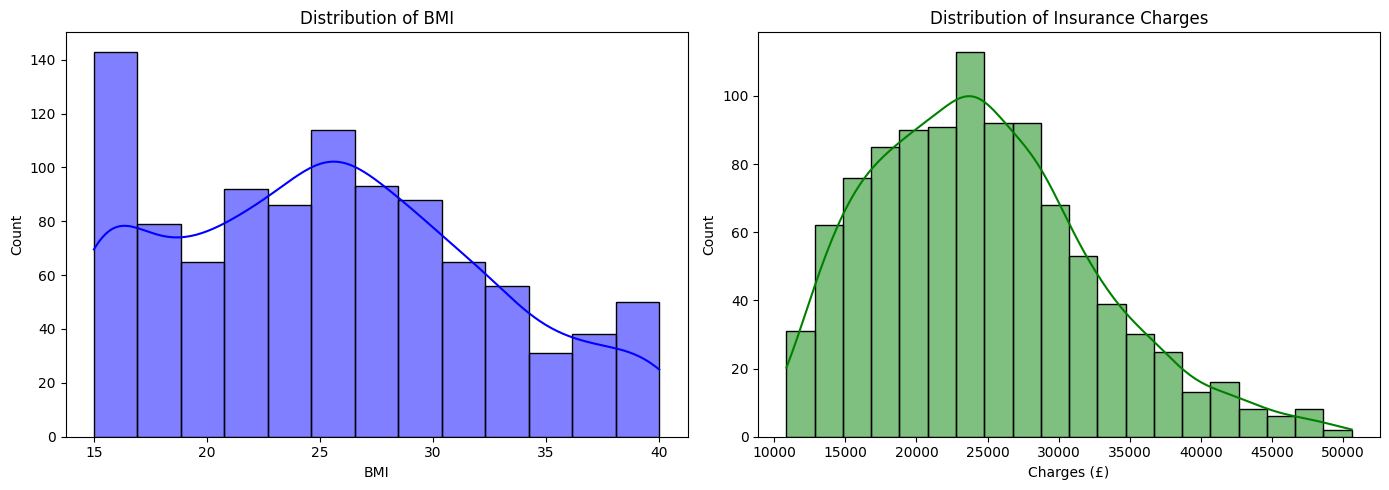

In [5]:
# Create a layout with two plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot the distribution of BMI
sns.histplot(data['bmi'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of BMI')
axes[0].set_xlabel('BMI')

# 2. Plot the distribution of Charges
sns.histplot(data['charges'], kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of Insurance Charges')
axes[1].set_xlabel('Charges (£)')

plt.tight_layout()
plt.show()

In [6]:
from scipy import stats

# Calculate Pearson correlation coefficient and p-value
correlation, p_value = stats.pearsonr(data['bmi'], data['charges'])

print("--- Statistical Test Results ---")
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"p-value: {p_value:.4e}")

--- Statistical Test Results ---
Pearson Correlation Coefficient: 0.7088
p-value: 2.0580e-153


# **Summary of Results: BMI vs. Insurance Charges**

**1. Pearson Correlation Coefficient: 0.7088**

What it means: This value indicates a strong positive linear relationship between an employee's BMI and their medical insurance charges.
Interpretation: As an employee's BMI increases, their insurance charges tend to increase significantly. Because the value is above 0.70, it is considered a powerful, dominant factor in determining the cost.

**2. p-value: $2.0580 \times 10^{-153}$**

**What it means:** The e-153 is scientific notation, meaning the number is a decimal point followed by 152 zeros before the 2 ($0.0000...002$).

**Interpretation:** In data science, if a p-value is less than 0.05, the result is considered statistically significant. The p-value is effectively zero, meaning there is virtually a 0% chance that this upward trend happened by random coincidence. The relationship is highly dependable.


**Business Insight for the Management Team**

There is a statistically verifiable, strong upward link between higher BMI measurements and increased insurance claim costs. If the firm opts for the competitive insurer that charges extra for employees outside the 18–24 BMI range, the data supports that those premium adjustments are based on concrete risk scaling rather than arbitrary bias.


# **State Limitations and Biases**

While the analytical results are statistically robust, a rigorous data science evaluation requires noting the following internal and external limitations:

**Correlation $\neq$ Causation:** While a higher BMI strongly correlates with increased cost structures, this single dimension does not dynamically prove direct biological causation for every single individual claim.

**Linearity Constraint:** The Pearson formula measures strictly linear patterns. If real-world insurance risk actually scales exponentially or via sudden threshold brackets (e.g., risk exploding abruptly only after crossing the Obese Class I line at BMI $\ge 30$), standard linear models will miscalculate the localized impact.

**Omitted Variable Bias:** This analysis lacks critical medical and contextual baseline parameters, most notably smoking status, historical pre-existing conditions, or specific workplace hazards. In standard actuaries, a high BMI paired with a non-smoker presents a vastly different risk curve than a high BMI paired with a smoker. Omitting this data forces BMI to capture error variance from hidden variables.





# Reflect

Write a brief paragraph highlighting your process and the rationale to showcase critical thinking and problem-solving.

To systematically evaluate the impact of lifestyle demographics on corporate healthcare costs, I conducted an end-to-end analytical workflow. I performed an exploratory data review using descriptive summary statistics and generated targeted distribution charts. I then executed a Pearson correlation analysis to mathematically isolate the impact of employee BMI against total insurance charges.

My analysis revealed a statistically powerful positive correlation ($r = 0.7088$) that is highly significant ($p < 0.001$), confirming that insurance premium structures scale alongside BMI. For the management team, this offers objective, data-driven justification for the proposed premium tiers, mitigating accusations of arbitrary organizational bias.

However, the business must remember the limitations of this analysis: the model assumes strict linearity and omits critical confounding risk indicators—such as tobacco usage or historical clinical backgrounds—which must be accounted for before finalizing targeted health policies.
